In [1]:
import os
import json
from time import time

# using async memory allocator to avoid some cuda allocation errors
# see: https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
# and turning off debugging info to clean up output during final run
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

# the "noqa: E402" comments below are to stop the linting tool I'm using from picking these up as not being at top of file
# this has been done as the above env. variables need to be set before we import tensorflow
import tensorflow as tf  # noqa: E402
import keras_tuner as kt  # noqa: E402

from modules.datastore import load_datasets,save_hp_search,load_hp_searches  # noqa: E402
from modules.helper_functions import display_samples,eval_model,show_incorrect_predictions  # noqa: E402
from modules.model_constructor import CustomHyperModel  # noqa: E402

# setting matplot so it renders in the notebook
%matplotlib inline

# we also want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


In [2]:
# first set some initial data up
dataset_path = 'datasets/CompositeDS/'
class_map = {0:"Original", 1:"Poisoned"}

# we need to remove any corrupted images so run clean_dataset notebook first
# see: https://github.com/tensorflow/tpu/issues/455
# and: https://stackoverflow.com/questions/57674314/images-png-jpg-or-jpeg-is-detected-as-corrupt-with-pythons-pil-pillow-veri

# set the batch size and image resolution as we'll keep these static
batch_size=32
image_resolution=512

Generating preview for train dataset, which contains ~13984 samples:


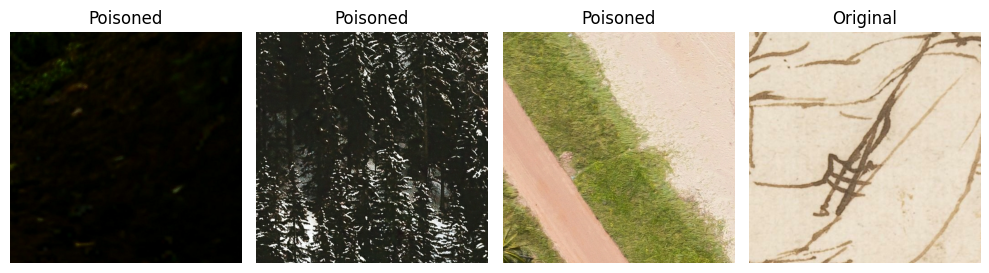

Generating preview for validation dataset, which contains ~3008 samples:


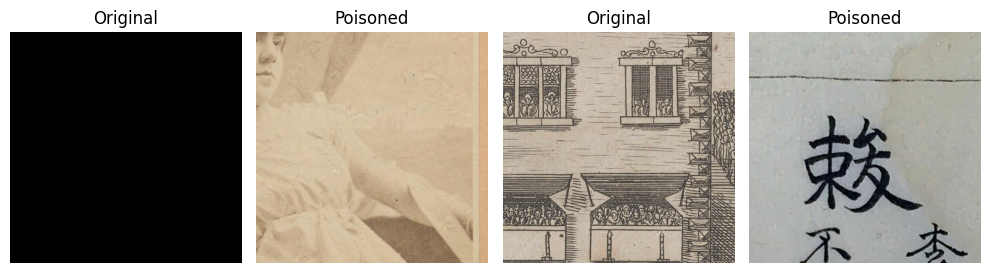

Generating preview for test dataset, which contains ~3008 samples:


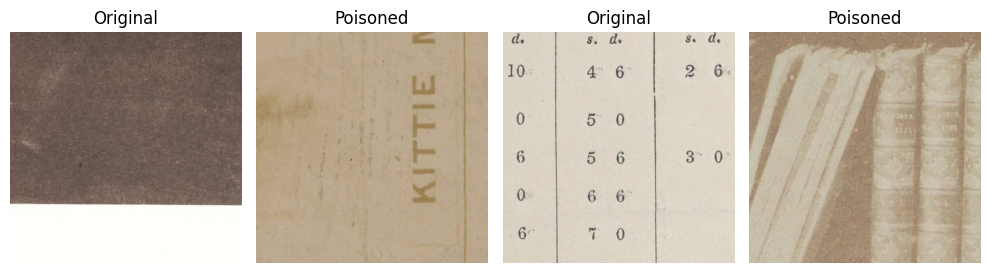

In [3]:
# let's test loading our dataset by generating a preview for each dataset
ds = load_datasets(dataset_path, batch_size, image_resolution)
for n, d in ds.items():
    print(f"Generating preview for {n} dataset, which contains ~{len(d)*batch_size} samples:")
    display_samples(d,class_map,grid_shape=(1,4))

In [4]:
# we don't want to have to retype all this for each trial so we need something that can be called for various hp search algorithms, image sizes and resizing methods
def run_trials(train_ds, val_ds, max_epochs, image_size, tuner_args):
    """
    For a given hyperparameter optimisation algorithm, image size and resizing method will run a hyperparameter search and save the results to the models\search_results folder.
    
    Results will be stored in csv format with name in format "{search_algo}_size{image_size}_crop{crop_and_pad}.csv".
    
    Args:
        train_ds (TF Dataset): TensorFlow dataset for training
        val_ds (TF Dataset): TensorFlow dataset for validation
        max_epochs (int): maximum number of epochs for each trial
        image_size (int): maximum height/width of the images
        tuner_args (dict): dictionary with kwargs for tuner object
    """    
    # start a timer so we can review execution time
    start = time()
    
    # set up our tuner with kwargs passed to run_trials
    tuner = kt.BayesianOptimization(**tuner_args)

    # set up the callback for early stopping
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
    ]

    # and then begin the search
    tuner.search(
        train_ds,
        epochs=max_epochs,
        callbacks=[callbacks],
        validation_data=val_ds
    )
    
    # calculate the runtime
    runtime = time() - start
    
    # lastly we'll save the top 20 results and update the comparison file needed
    save_hp_search(tuner,runtime,num_to_save=20,save_folder='results')

Before running anything we want to check how long it's going to take and tweak until we're expecting runtime <48 hours. This likely a pessimistic estimate due to our use of early stopping and skipping over large models.

We have six different searches to run, three with hyperband and three with bayesian optimisation so we calculate how long they'll take approximately with the below then tweak values as required.

In [5]:
# bayesian optimisation
# https://keras.io/api/keras_tuner/tuners/bayesian/#bayesianoptimization-class
max_epochs=15
max_trials=60
expected_epochs=max_epochs*max_trials
runtime_seconds=expected_epochs*65

print(f"Bayesian optimisation will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

Bayesian optimisation will run for a maximum of 900 epochs.
This is expected to take no more than 16.25 hours.


Now we've got a method for running trials, and a reasonable estimate for the time frame, we can start training.

In [6]:
# set up the options for the hypertuner
tuner_args = {
    "hypermodel": CustomHyperModel(input_shape=(image_resolution,image_resolution) + (3,)),
    "objective": 'val_accuracy',
    "max_trials": max_trials,
    "max_model_size": 1.8e6, # added this to try and avoid us ending up with oversized models and OOM errors
    "beta": 4,
    "max_retries_per_trial": 2, # we'll retry a few times but these are probably memory errors
    "max_consecutive_failed_trials": 50, # trials skipped due to max_model_size contribute to this counter!
    "directory": 'autotune',
    "project_name": 'final_run'
}

# now we can run our trials, we'll also keep a record of how long each took
run_trials(ds['train'], ds['validation'], max_epochs, image_resolution, tuner_args)

Trial 60 Complete [00h 14m 45s]
val_accuracy: 0.9719251394271851

Best val_accuracy So Far: 0.9886363744735718
Total elapsed time: 11h 14m 23s

Top 20 results for final_run saved to: results/search_results/final_run.csv
Top 20 results saved to: results/hpsearch_comparison.json



Now let's load and take a peek at our results and put the best result aside for further training.

In [16]:
# load the results and set up a dict to store the best from each trial
results = load_hp_searches(load_folder='results/search_results/',metric='val_accuracy')
best_results = {results[0]['optimiser_name']: results[0]}

# commenting out the part below as might want to use in future to experiment with results with different optimiser
print('Make sure we have all the results loaded:')
for result in results:
    #if result['optimiser_name'] not in best_results.keys():
    #    best_results.update({result['optimiser_name']:result})
    print(f"{result['optimiser_name']}, {result['val_accuracy']}")

# make sure we loaded the best one OK
print('\nBest result:')
for k,v in best_results.items():
    print(f"{k}: {v}")

Make sure we have all the results loaded:
AdamW, 0.9886363744735718
AdamW, 0.9869652390480042
AdamW, 0.9859625697135925
Adam, 0.9836229681968689
SGD, 0.9829545617103577
Adam, 0.9809492230415344
Adam, 0.9792780876159668
Adam, 0.9786096215248108
Adam, 0.9782754182815552
Adam, 0.9769384860992432
Adam, 0.9762700796127319
Adam, 0.9752673506736755
Adam, 0.9739304780960083
Adam, 0.9732620120048523
AdamW, 0.9732620120048523
AdamW, 0.9725936055183411
Adam, 0.9719251394271851
Adam, 0.9692513346672058
SGD, 0.9679144620895386
AdamW, 0.9665775299072266

Best result:
AdamW: {'trial': 'final_run', 'optimiser_name': 'AdamW', 'learning_rate': '0.00014280500000000003', 'weight_decay': '0.1', 'conv1_filters': '32', 'residual_connections': 'False', 'block_repetitions': '3', 'block_1_filters': '128', 'block_2_filters': '256', 'block_3_filters': '384', 'final_conv_filters': '576', 'dropout': '0.25', 'val_accuracy': '0.9886363744735718', 'block_4_filters': '', 'momentum': ''}


Set up a method to load a model from the trial data

In [21]:
# should probably refactor this... not an ideal method as needs updating every time I add or remove hyperparameters
def load_from_trial(trial_data):
    # filter the trial_data to get what we need and convert the hyperparameters to the correct datatype
    params = {
        "optimiser_name": trial_data['optimiser_name'],
        'learning_rate': float(trial_data['learning_rate']),
        # some of these may be null so need to check first
        "weight_decay": None if trial_data['optimiser_name'] != 'AdamW' else float(trial_data['weight_decay']),
        "momentum": None if trial_data['optimiser_name'] != 'SGD' else float(trial_data['momentum']),
        'conv1_filters': int(trial_data['conv1_filters']),
        'residual_connections': bool(trial_data['residual_connections']),
        'block_repetitions': int(trial_data['block_repetitions']),
        'block_1_filters': int(trial_data['block_1_filters']),
        'block_2_filters': int(trial_data['block_2_filters']),
        # some of these may be null so need to check first
        'block_3_filters': None if int(trial_data['block_repetitions'])<3 else int(trial_data['block_3_filters']),
        'block_4_filters': None if int(trial_data['block_repetitions'])<4 else int(trial_data['block_4_filters']),
        'final_conv_filters': int(trial_data['final_conv_filters']),
        'dropout': float(trial_data['dropout'])
    }
    # print the details of the model before we build it
    print(f"Loading model from trial {trial_data['trial']}.")
    print(f"Parameters:\n{params}\n")
    # lastly we can use CustomHyperModel to build a model for us
    hypermodel = CustomHyperModel(input_shape=(image_resolution,image_resolution) + (3,))
    model = hypermodel.model_builder(**params)
    return model

Now for the best model(s):

 • create a model with the associated hyperparameters;

 • train the model until it stops improving

 • checkpointing the model if its the best seen thus far;

 • reload the best performing checkpoint and evaluate against the validation and test datasets; and
 
 • finally save our training history to a file.


Model_AdamW already exists, proceeding to load model and history from file.

Summary of model_AdamW:
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 rescaling_5 (Rescaling)     (None, 512, 512, 3)          0         ['input_6[0][0]']             
                                                                                                  
 conv2d_19 (Conv2D)          (None, 256, 256, 32)         896       ['rescaling_5[0][0]']         
                                                                                                  
 batch_normalization_38 (Ba  (None, 256, 256, 32)         128       ['conv2d_19[0][0]']  

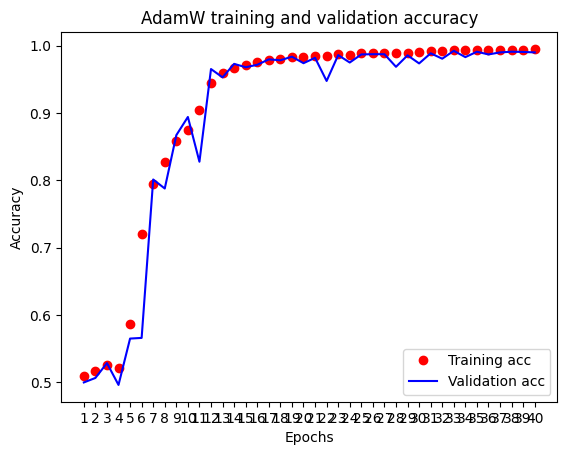

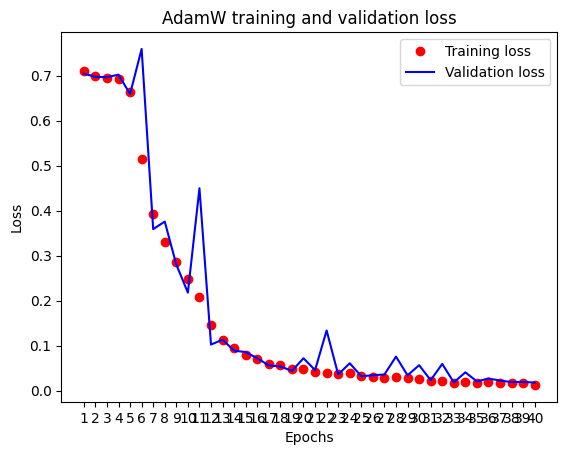


AdamW evaluation on validation data
loss: 0.0
tp: 1478.0
fp: 8.0
tn: 1487.0
fn: 19.0
accuracy: 0.9909759163856506
precision: 0.9946164488792419
recall: 0.9873079657554626
auc: 0.9997710585594177

AdamW evaluation on test data
loss: 0.0
tp: 1482.0
fp: 6.0
tn: 1493.0
fn: 16.0
accuracy: 0.992659330368042
precision: 0.9959677457809448
recall: 0.9893190860748291
auc: 0.9995230436325073


In [34]:
# first create a dict to store our results in
training_results = {}

for trial_name, trial_data in best_results.items():
    # load the dataset and create the model
    if not (os.path.exists(f'results/models/{trial_name}/{trial_name}.keras') and os.path.exists(f'results/models/{trial_name}/{trial_name}_history.json')):
        model = load_from_trial(trial_data)
        # this time we're not going to stop early
        # but we will try and lower the learning rate when it stops improving to see if he we can settle into a better minimum
        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_delta=1e-3),
            tf.keras.callbacks.ModelCheckpoint(f'results/models/{trial_name}/{trial_name}.keras', monitor='val_loss', mode='min', save_best_only=True)
        ]
        # train the model and save the history, we'll set the max epochs such that ReduceLROnPlateau should kick in
        history = model.fit(
            ds['train'],
            epochs=40,
            verbose=1,
            callbacks=callbacks,
            validation_data=ds['validation'],
        ).history
        # now save the history, removing lr as we don't want it and json library doesn't seem to like serialising it (presuming needs conversion to str)
        del history["lr"]
        json.dump(history, open(f'results/models/{trial_name}/{trial_name}_history.json', 'w'), indent="\t")
    else:
        print(f'\nModel_{trial_name} already exists, proceeding to load model and history from file.\n')
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/models/{trial_name}/{trial_name}.keras')
    history = json.load(open(f'results/models/{trial_name}/{trial_name}_history.json', 'r'))
    # save a visualisation of the model for use in our report
    tf.keras.utils.plot_model(model,show_shapes=True,to_file=f'results/models/{trial_name}/{trial_name}.png')
    # generate a textual model summary (useful as it has params per layer)
    print(f'Summary of model_{trial_name}:')
    model.summary()
    # print the history and evaluate the model
    evaluation = eval_model(trial_name,model,history,ds['validation'],ds['test'])
    # put the evaluation results into the dict we created earlier
    training_results.update({trial_name:evaluation})

# save all of the results for review in external program(s)
json.dump(training_results, open('results/training_results.json', 'w'), indent="\t")

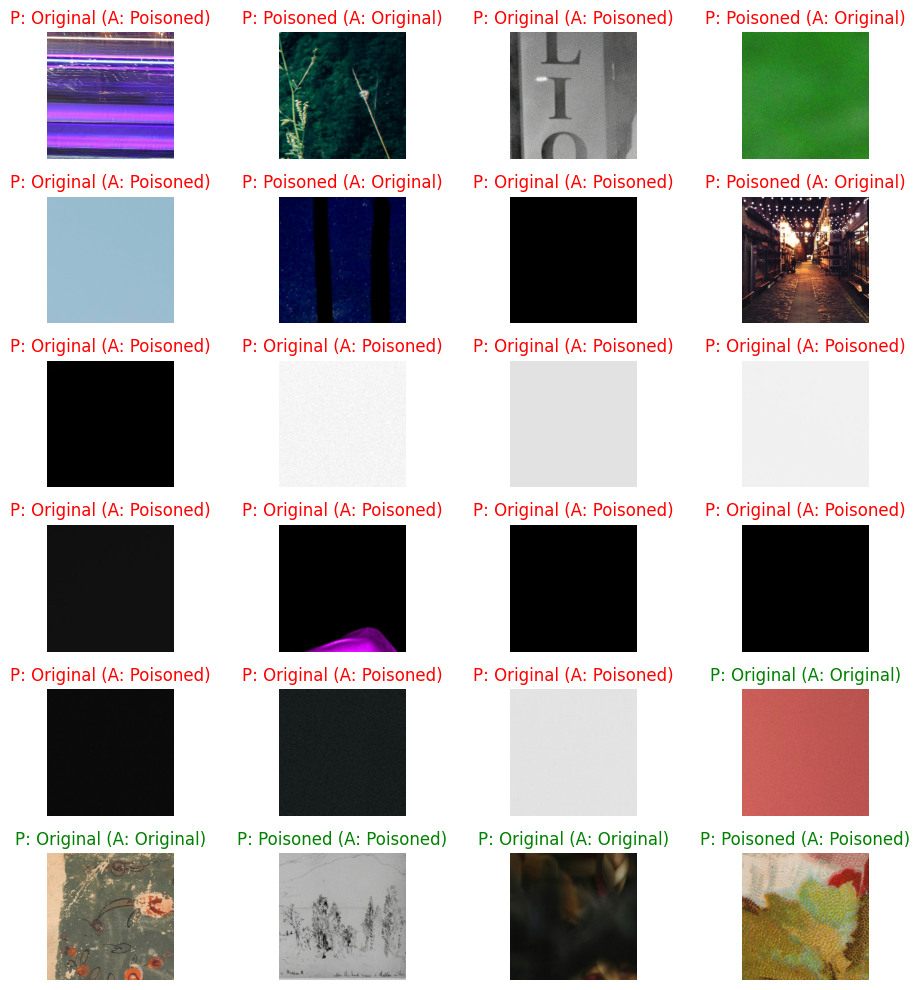

In [40]:
# now for each trial in best results reload the model and display some predictions
for trial_name, trial_data in best_results.items():
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/models/{trial_name}/{trial_name}.keras')
    show_incorrect_predictions(model, ds['test'], class_map, grid_shape=(6, 4))
    # once done we can save for export
    tf.keras.models.save_model(model, 'results/models/export/to_export.keras')